# 01 – Eksploracyjna Analiza Danych (EDA)
**Dataset:** Heart Disease UCI – Cleveland

Celem notebooka jest zrozumienie struktury danych przed budowaniem modelu

## 1. Import bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Wczytanie danych

In [2]:
df = pd.read_csv('../data/heart.csv')
print(f"Rozmiar: {df.shape[0]} wierszy x {df.shape[1]} kolumn")
df.head(10)

Rozmiar: 303 wierszy x 14 kolumn


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 3. Podstawowe informacje

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [4]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.94
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,4.00


## 4. Brakujące wartości
Dataset Cleveland używa `?` jako brakujące wartości.

In [5]:
df_clean = df.replace('?', np.nan)
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
pd.DataFrame({'Brakujące': missing, 'Procent (%)': missing_pct})[missing > 0]

,Brakujące,Procent (%)
ca,4,1.32
thal,2,0.66


## 5. Rozkład zmiennej docelowej (target)
`0` = brak choroby, `1–4` = choroba serca (sprowadzamy do binarnego 0-1)

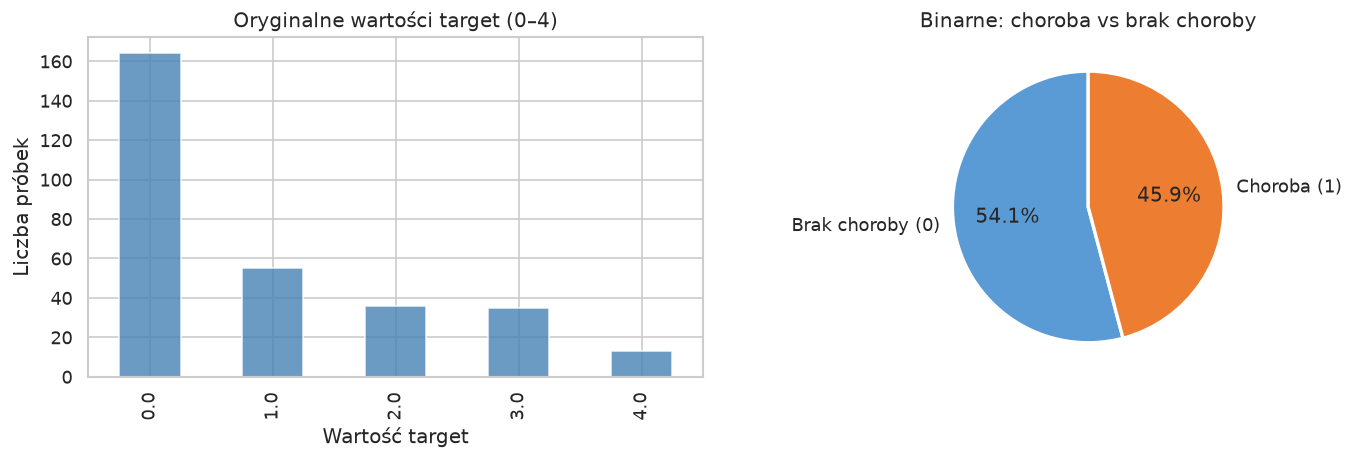

Brak choroby: 164 (54.1%)
Choroba:      139 (45.9%)


In [6]:
df_clean = df_clean.astype(float)
df_clean['target_bin'] = (df_clean['target'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Oryginalne wartości
df_clean['target'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.8, edgecolor='white'
)
axes[0].set_title('Oryginalne wartości target (0–4)')
axes[0].set_xlabel('Wartość target')
axes[0].set_ylabel('Liczba próbek')

# Binarne
labels = ['Brak choroby (0)', 'Choroba (1)']
counts = df_clean['target_bin'].value_counts().sort_index()
axes[1].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#5B9BD5', '#ED7D31'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Binarne: choroba vs brak choroby')

plt.tight_layout()
plt.show()

print(f"Brak choroby: {counts[0]} ({counts[0]/len(df_clean)*100:.1f}%)")
print(f"Choroba:      {counts[1]} ({counts[1]/len(df_clean)*100:.1f}%)")

## 6. Rozkłady cech numerycznych

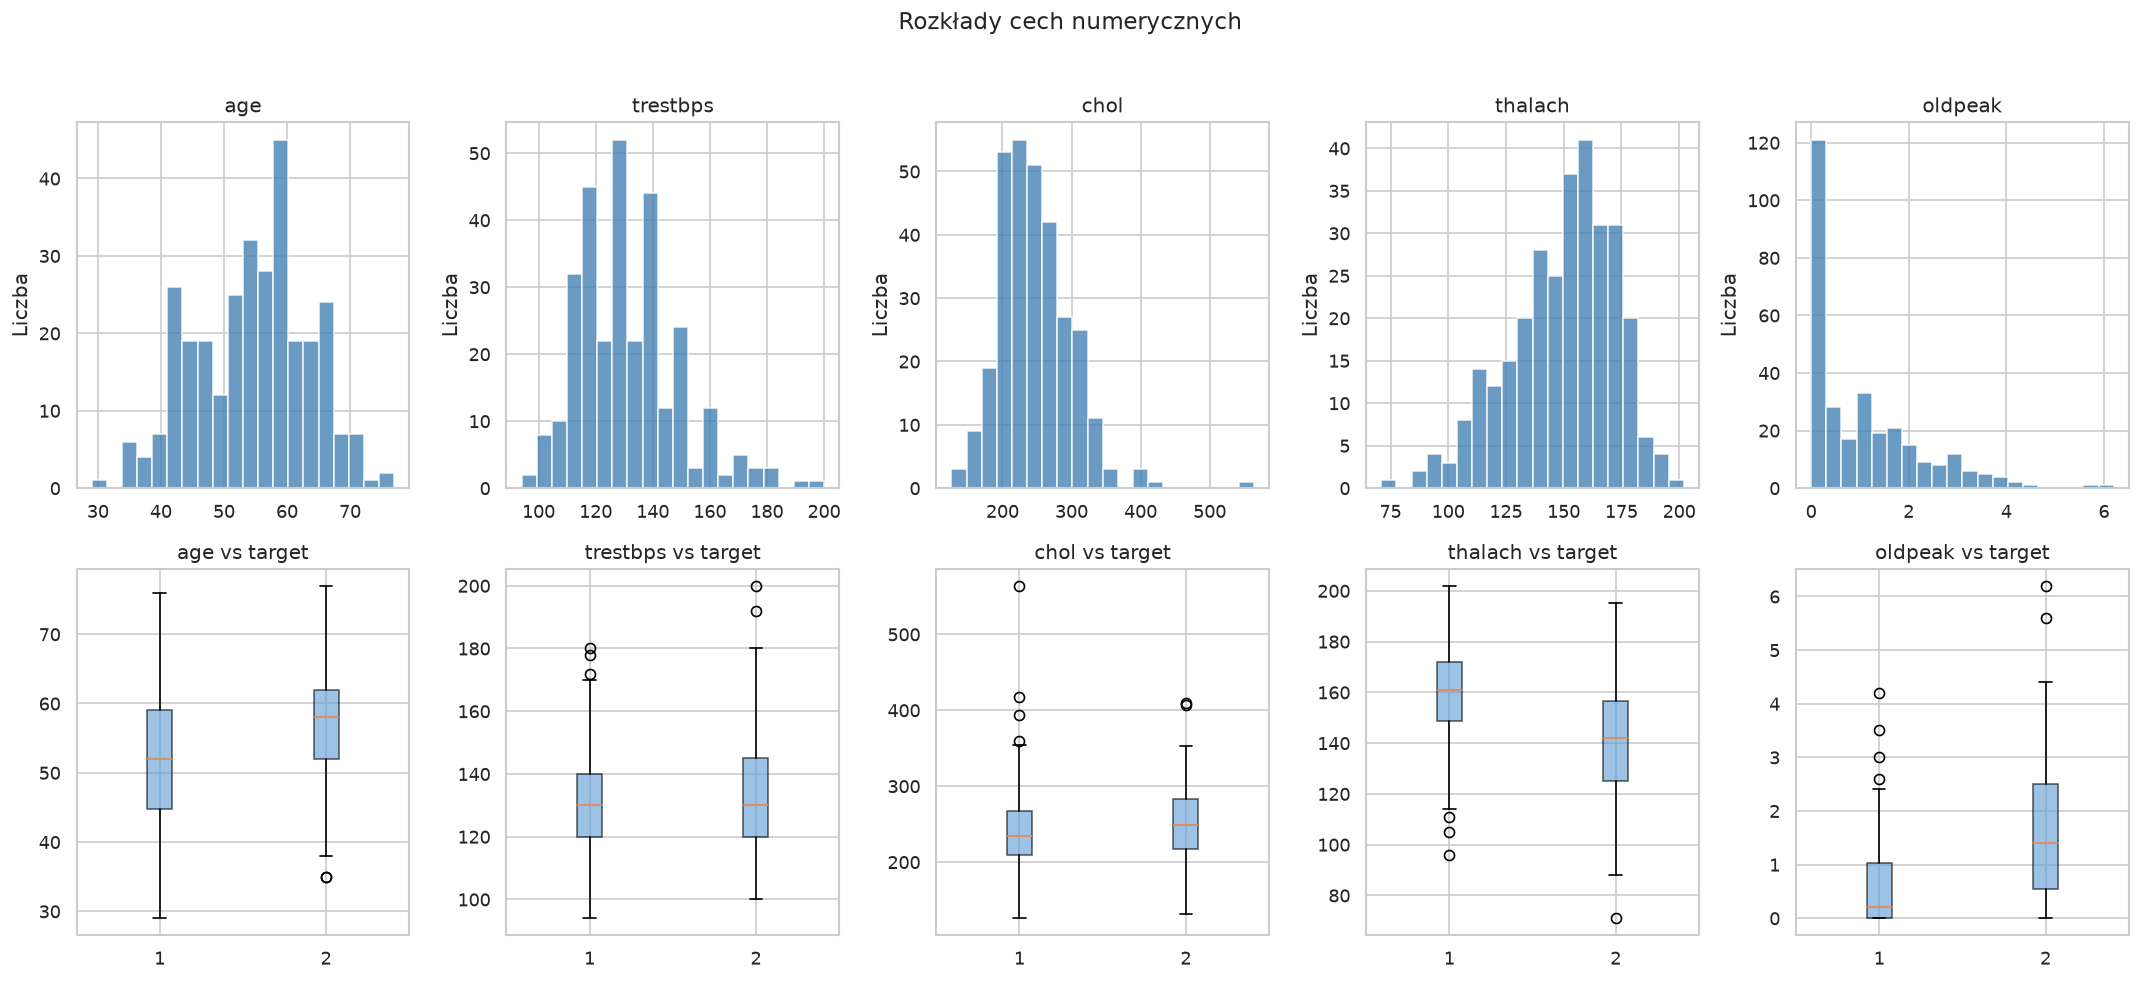

In [7]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, col in enumerate(num_cols):
    # Histogram
    df_clean[col].hist(ax=axes[0, i], bins=20, color='steelblue',
                       alpha=0.8, edgecolor='white')
    axes[0, i].set_title(col)
    axes[0, i].set_ylabel('Liczba')

    # Box plot wg targetu
    data_0 = df_clean.loc[df_clean['target_bin'] == 0, col].dropna()
    data_1 = df_clean.loc[df_clean['target_bin'] == 1, col].dropna()
    axes[1, i].boxplot([data_0, data_1], label=['Brak', 'Choroba'],
                       patch_artist=True,
                       boxprops={'facecolor': '#5B9BD5', 'alpha': 0.6})
    axes[1, i].set_title(f'{col} vs target')

plt.suptitle('Rozkłady cech numerycznych', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Cechy kategoryczne vs target

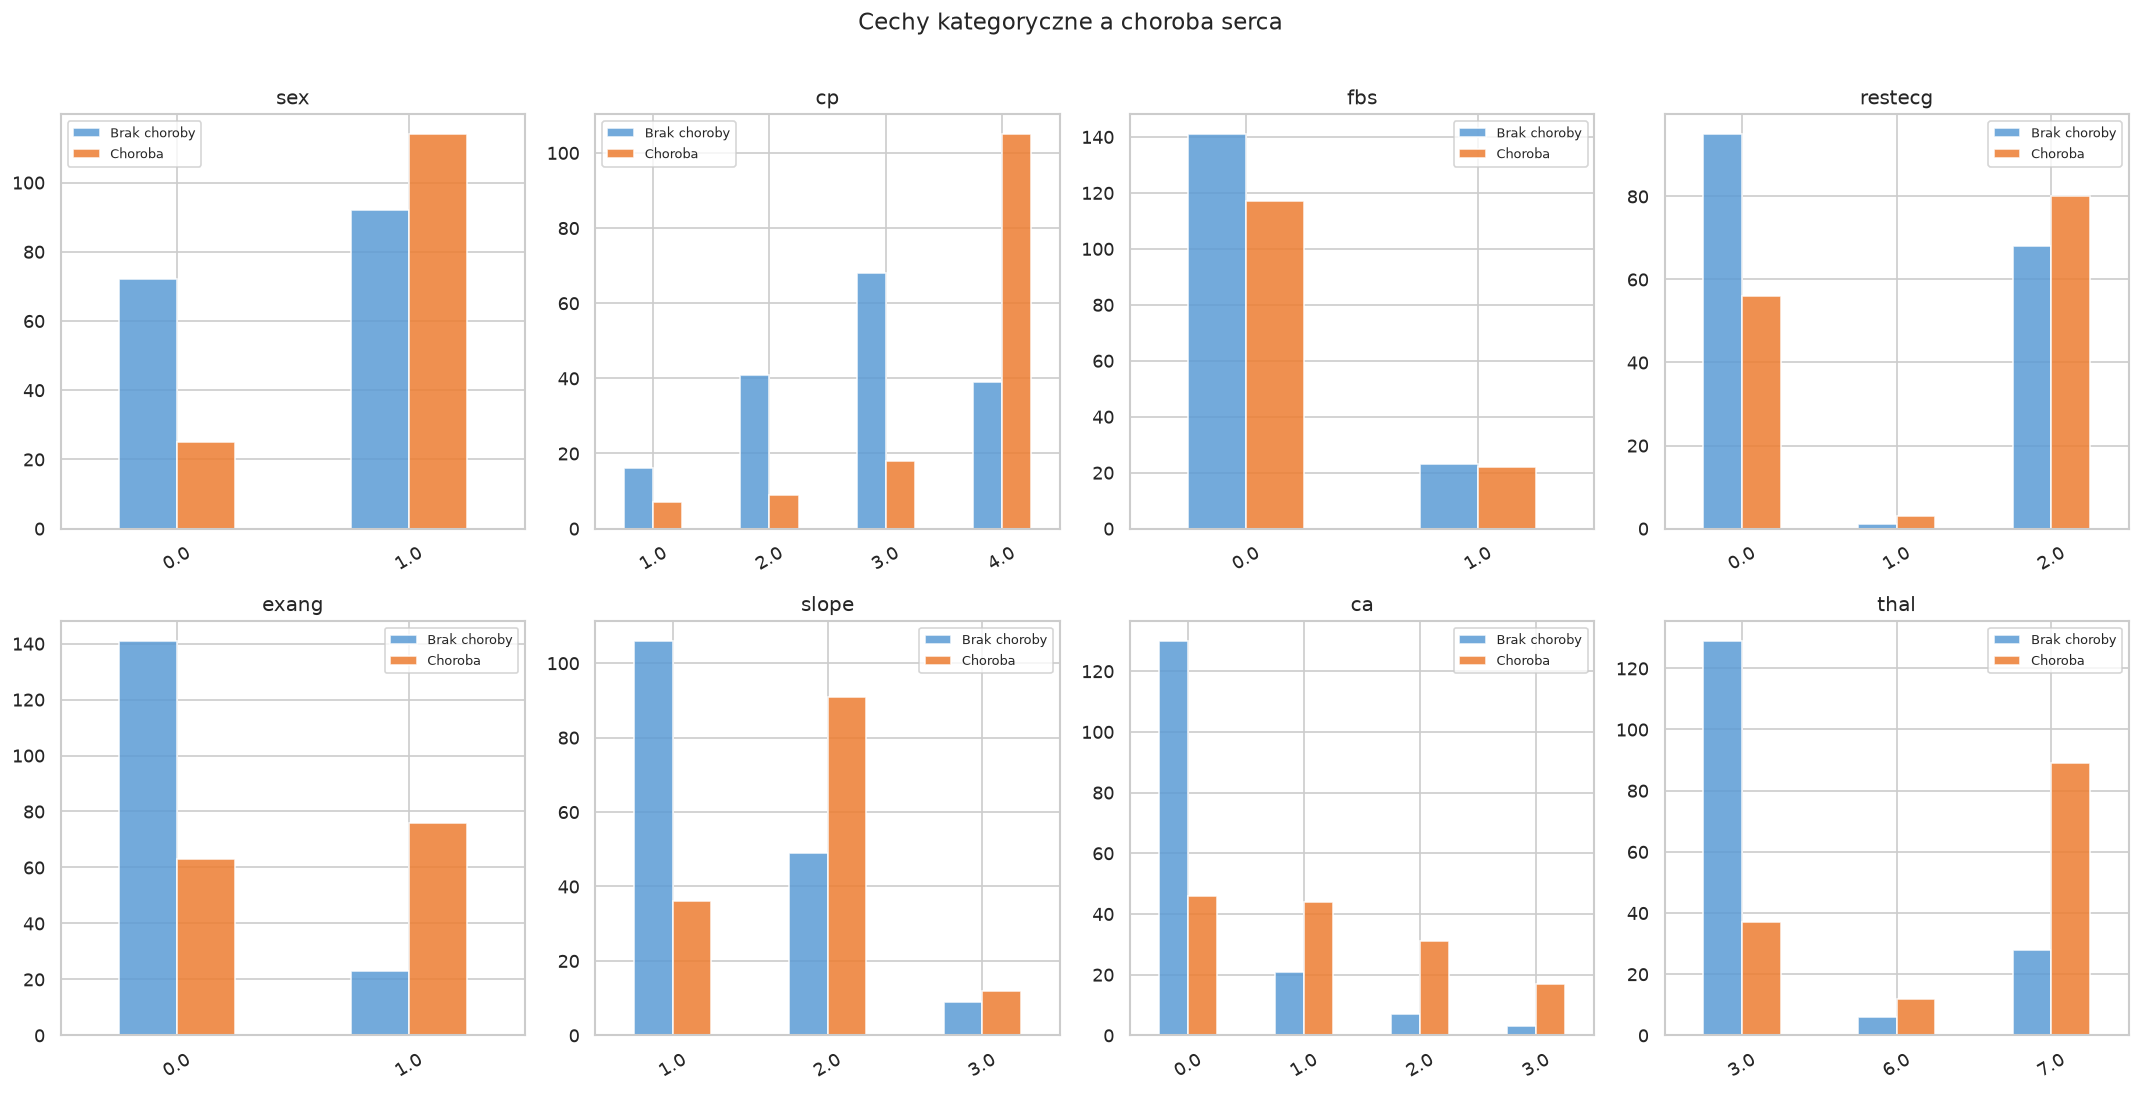

In [8]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = {
    'sex':     {0: 'Kobieta', 1: 'Mężczyzna'},
    'cp':      {0: 'Typowy', 1: 'Atypowy', 2: 'Nieangina', 3: 'Bezob.'},
    'fbs':     {0: '≤120', 1: '>120'},
    'restecg': {0: 'Normalny', 1: 'ST-T', 2: 'LVH'},
    'exang':   {0: 'Nie', 1: 'Tak'},
    'slope':   {0: 'Rosnący', 1: 'Płaski', 2: 'Malejący'},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df_clean.groupby([col, 'target_bin']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#5B9BD5', '#ED7D31'],
            alpha=0.85, edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(['Brak choroby', 'Choroba'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Cechy kategoryczne a choroba serca', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Macierz korelacji

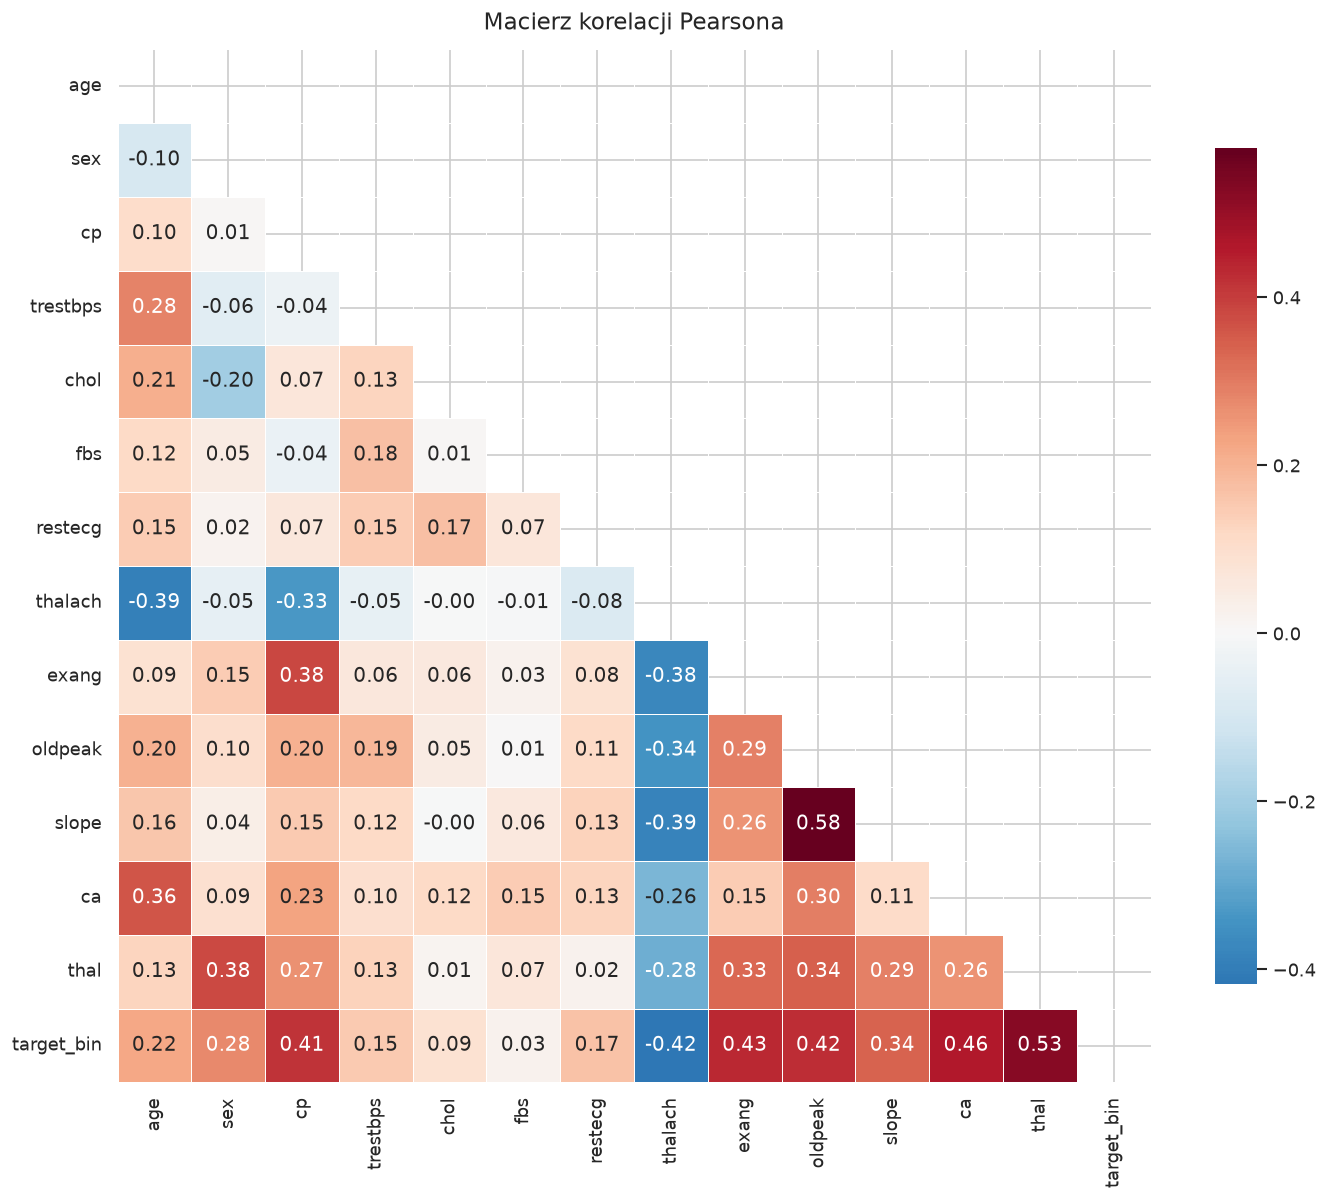

In [9]:
df_corr = df_clean.drop('target', axis=1).copy()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Macierz korelacji Pearsona', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## 9. Wnioski z EDA

- **Rozkład klas**: ~54% brak choroby, ~46% choroba – klasy są względnie zrównoważone
- **Najsilniejsza korelacja z target**: `cp` (ból w klatce), `thalach` (max tętno), `exang` (dławica wysiłkowa), `oldpeak`
- **Brakujące wartości**: tylko w `ca` i `thal` (4–6 próbek) – uzupełnione medianą
- **Outliers**: `chol` ma kilka ekstremów, ale RF jest odporny na wartości skrajne